# Clasificador de Perceptos de Implantes Retinales

## Objetivo
Entrenar modelos de deep learning para clasificar perceptos de implantes retinales en 4 clases (person, car, chair, dining table). Se comparan tres enfoques:
- **KNN baseline**: k-nearest neighbors por implante
- **CNN**: Red convolucional independiente por implante
- **CNN+GRU**: Secuencia temporal de 3 implantes con RNN

## Dataset
- 4 clases de objetos × 3 implantes = 12 combinaciones
- Imágenes de 256×256 píxeles en escala de grises
- Split: 70% train, 15% val, 15% test

In [1]:
# Dar acceso de Drive + Cloud a este runtime de Colab Enterprise.
# Usá tu CUENTA PERSONAL.
# Esta celda ya no revoca credenciales cada vez: solo pide login si hace falta.

from pathlib import Path

OAUTH_CLIENT_FILE = "/home/jupyter/oauth_client.json"
ADC_FILE = Path.home() / ".config" / "gcloud" / "application_default_credentials.json"

if ADC_FILE.exists():
    print("ADC ya existe. No vuelvo a pedir login.")
    print("Archivo:", ADC_FILE)
else:
    print("No encontré ADC. Inicio login con cuenta personal.")
    !gcloud auth application-default login \
        --client-id-file="{OAUTH_CLIENT_FILE}" \
        --scopes="https://www.googleapis.com/auth/drive,https://www.googleapis.com/auth/cloud-platform" \
        --no-browser

No encontré ADC. Inicio login con cuenta personal.

You are running on a Google Compute Engine virtual machine.
The service credentials associated with this virtual machine
will automatically be used by Application Default
Credentials, so it is not necessary to use this command.

If you decide to proceed anyway, your user credentials may be visible
to others with access to this virtual machine. Are you sure you want
to authenticate with your personal account?

Do you want to continue (Y/n)?  y

You are authorizing client libraries without access to a web browser. Please run the following command on a machine with a web browser and copy its output back here. Make sure the installed gcloud version is 372.0.0 or newer.

gcloud auth application-default login --remote-bootstrap="https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=349436352845-m6a3foc5tsuhs48pmurgfll2g1jurreu.apps.googleusercontent.com&scope=https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fdrive+https%3A%2F%2Fwww

### Autenticación Google Drive
Configura acceso a Google Drive y descarga datos desde carpeta compartida. Descarga:
- Código fuente (`src/`)
- Metadatos (`metadata/`)
- Perceptos generados (`percepts/`)
- Máscaras originales (`masks/`)
- Modelos/métricas existentes (`outputs/`)

In [2]:
!gcloud auth application-default print-access-token | head -c 20

ya29.a0AT3oNZ8sSCzC3

### Verificación de autenticación
Valida que la autenticación con Google Drive esté funcionando correctamente

In [3]:
# setup Colab Enterprise + Drive compartido
# IMPORTANTE:
# 1) Pegá el ID de la carpeta raíz compartida en DRIVE_PROJECT_FOLDER_ID.
#    Ejemplo: https://drive.google.com/drive/folders/ABC123 -> ID = ABC123
# 2) Corré esta celda primero. Autenticá con tu CUENTA PERSONAL.

!pip install -q torch torchvision matplotlib scikit-learn seaborn pandas pillow joblib \
    google-api-python-client google-auth google-auth-httplib2 tqdm

from pathlib import Path
import sys
import io
import os
import time
import mimetypes

# --- CAMBIAR ESTO ---
DRIVE_PROJECT_FOLDER_ID = "1cUFjG2-h_7dgjlrvp8Wxo600afMYlOUl"
PROJECT_ROOT = Path("/home/jupyter/tp_final_vision_artificial")
# --------------------




import google.auth
from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseDownload, MediaFileUpload

SCOPES = [
    "https://www.googleapis.com/auth/drive",
    "https://www.googleapis.com/auth/cloud-platform",
]

creds, _ = google.auth.default(scopes=SCOPES)
drive_service = build("drive", "v3", credentials=creds)


def _q(s: str) -> str:
    """Escapa strings para queries de Drive API."""
    return s.replace("\\", "\\\\").replace("'", "\\'")


def list_drive_children(folder_id: str):
    items = []
    page_token = None
    while True:
        resp = drive_service.files().list(
            q=f"'{folder_id}' in parents and trashed=false",
            spaces="drive",
            fields="nextPageToken, files(id, name, mimeType, size, modifiedTime)",
            pageToken=page_token,
            supportsAllDrives=True,
            includeItemsFromAllDrives=True,
        ).execute()
        items.extend(resp.get("files", []))
        page_token = resp.get("nextPageToken")
        if not page_token:
            break
    return items


def download_drive_file(file_id: str, local_path: Path):
    local_path.parent.mkdir(parents=True, exist_ok=True)
    request = drive_service.files().get_media(fileId=file_id, supportsAllDrives=True)
    with io.FileIO(local_path, "wb") as fh:
        downloader = MediaIoBaseDownload(fh, request)
        done = False
        while not done:
            _, done = downloader.next_chunk()


def download_drive_folder(folder_id: str, local_dir: Path, skip_existing: bool = True):
    """Descarga recursivamente una carpeta de Drive a una carpeta local del runtime."""
    local_dir.mkdir(parents=True, exist_ok=True)
    children = list_drive_children(folder_id)

    for item in children:
        name = item["name"]
        mime_type = item["mimeType"]
        item_id = item["id"]
        local_path = local_dir / name

        if mime_type == "application/vnd.google-apps.folder":
            download_drive_folder(item_id, local_path, skip_existing=skip_existing)
        elif mime_type.startswith("application/vnd.google-apps."):
            print(f"Saltando archivo Google nativo no descargable directo: {local_path}")
        else:
            if skip_existing and local_path.exists():
                continue
            print(f"Descargando: {local_path}")
            download_drive_file(item_id, local_path)


def get_or_create_drive_folder(parent_id: str, name: str):
    resp = drive_service.files().list(
        q=(
            f"'{parent_id}' in parents and "
            f"name='{_q(name)}' and "
            "mimeType='application/vnd.google-apps.folder' and trashed=false"
        ),
        spaces="drive",
        fields="files(id, name)",
        supportsAllDrives=True,
        includeItemsFromAllDrives=True,
    ).execute()

    files = resp.get("files", [])
    if files:
        return files[0]["id"]

    meta = {
        "name": name,
        "mimeType": "application/vnd.google-apps.folder",
        "parents": [parent_id],
    }
    created = drive_service.files().create(
        body=meta,
        fields="id",
        supportsAllDrives=True,
    ).execute()
    return created["id"]


def find_drive_file(parent_id: str, name: str):
    resp = drive_service.files().list(
        q=f"'{parent_id}' in parents and name='{_q(name)}' and trashed=false",
        spaces="drive",
        fields="files(id, name, mimeType)",
        supportsAllDrives=True,
        includeItemsFromAllDrives=True,
    ).execute()
    files = resp.get("files", [])
    return files[0] if files else None


def upload_or_update_file(local_file: Path, parent_id: str):
    mime_type = mimetypes.guess_type(str(local_file))[0] or "application/octet-stream"
    media = MediaFileUpload(str(local_file), mimetype=mime_type, resumable=True)

    existing = find_drive_file(parent_id, local_file.name)
    if existing and existing["mimeType"] != "application/vnd.google-apps.folder":
        drive_service.files().update(
            fileId=existing["id"],
            media_body=media,
            supportsAllDrives=True,
        ).execute()
    else:
        meta = {"name": local_file.name, "parents": [parent_id]}
        drive_service.files().create(
            body=meta,
            media_body=media,
            fields="id",
            supportsAllDrives=True,
        ).execute()


def upload_folder_recursive(local_dir: Path, drive_parent_id: str):
    """Sube o actualiza una carpeta local recursivamente en Drive."""
    local_dir = Path(local_dir)
    remote_dir_id = get_or_create_drive_folder(drive_parent_id, local_dir.name)

    for path in sorted(local_dir.iterdir()):
        if path.is_dir():
            upload_folder_recursive(path, remote_dir_id)
        elif path.is_file():
            print(f"Subiendo/actualizando: {path}")
            upload_or_update_file(path, remote_dir_id)


def sync_outputs_to_drive():
    """Sube PROJECT_ROOT/outputs a la carpeta compartida."""
    if OUTPUTS_DIR.exists():
        upload_folder_recursive(OUTPUTS_DIR, DRIVE_PROJECT_FOLDER_ID)
        print("Sync terminado:", OUTPUTS_DIR)
    else:
        print("No existe OUTPUTS_DIR todavía:", OUTPUTS_DIR)


def find_child_folder(parent_id: str, name: str):
    """Busca una carpeta hija por nombre dentro de una carpeta de Drive."""
    resp = drive_service.files().list(
        q=(
            f"'{parent_id}' in parents and "
            f"name='{_q(name)}' and "
            "mimeType='application/vnd.google-apps.folder' and trashed=false"
        ),
        spaces="drive",
        fields="files(id, name)",
        supportsAllDrives=True,
        includeItemsFromAllDrives=True,
    ).execute()

    files = resp.get("files", [])
    if not files:
        raise FileNotFoundError(
            f"No encontré la carpeta '{name}' dentro del folder_id={parent_id}"
        )
    return files[0]["id"]


# ------------------------------------------------------------
# Descarga selectiva desde Drive.
# NO descarga data/electrical_signals porque tiene demasiados archivos
# y este notebook de perceptos no los necesita.
# También descarga outputs/ si ya existe en Drive, para poder cargar modelos ya entrenados.
# ------------------------------------------------------------

PROJECT_ROOT.mkdir(parents=True, exist_ok=True)

# Carpetas principales dentro del proyecto compartido
DATA_FOLDER_ID = find_child_folder(DRIVE_PROJECT_FOLDER_ID, "data")
SRC_FOLDER_ID = find_child_folder(DRIVE_PROJECT_FOLDER_ID, "src")

# Subcarpetas necesarias dentro de data/
METADATA_FOLDER_ID = find_child_folder(DATA_FOLDER_ID, "metadata")
PERCEPTS_FOLDER_ID = find_child_folder(DATA_FOLDER_ID, "percepts")
MASKS_FOLDER_ID = find_child_folder(DATA_FOLDER_ID, "masks")

RAW_FOLDER_ID = find_child_folder(DATA_FOLDER_ID, "raw")
COCO_FOLDER_ID = find_child_folder(RAW_FOLDER_ID, "coco")
COCO_VAL2017_FOLDER_ID = find_child_folder(COCO_FOLDER_ID, "val2017")

# Estructura local
DATA_DIR = PROJECT_ROOT / "data"
PERCEPTS_DIR = DATA_DIR / "percepts"
SIGNALS_DIR = DATA_DIR / "electrical_signals"  # se define, pero NO se descarga
METADATA_DIR = DATA_DIR / "metadata"
MASKS_DIR = DATA_DIR / "masks"

RAW_DIR = DATA_DIR / "raw"
COCO_DIR = RAW_DIR / "coco"
COCO_IMAGES_DIR = COCO_DIR / "val2017"

OUTPUTS_DIR = PROJECT_ROOT / "outputs"
MODELS_DIR = OUTPUTS_DIR / "models"
METRICS_DIR = OUTPUTS_DIR / "metrics"
FIGURES_DIR = OUTPUTS_DIR / "figures"

# Descargamos solo lo necesario para correr el notebook
download_drive_folder(SRC_FOLDER_ID, PROJECT_ROOT / "src", skip_existing=False)
download_drive_folder(METADATA_FOLDER_ID, METADATA_DIR, skip_existing=True)
download_drive_folder(PERCEPTS_FOLDER_ID, PERCEPTS_DIR, skip_existing=True)
download_drive_folder(COCO_VAL2017_FOLDER_ID, COCO_IMAGES_DIR, skip_existing=True)
download_drive_folder(MASKS_FOLDER_ID, MASKS_DIR, skip_existing=True)

# Si ya existe outputs/ en Drive, lo bajamos también.
# Esto permite que Run all cargue modelos ya entrenados en vez de reentrenar.
outputs_remote = find_drive_file(DRIVE_PROJECT_FOLDER_ID, "outputs")

if outputs_remote and outputs_remote["mimeType"] == "application/vnd.google-apps.folder":
    print("Encontré outputs/ en Drive. Descargando modelos/métricas/figuras existentes...")
    download_drive_folder(outputs_remote["id"], OUTPUTS_DIR, skip_existing=True)
else:
    print("No encontré outputs/ en Drive todavía. Se creará al guardar resultados.")

# Creamos carpetas de salida locales
for d in [MODELS_DIR, METRICS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Para poder importar src.classification...
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)
print("METADATA_DIR:", METADATA_DIR)
print("PERCEPTS_DIR:", PERCEPTS_DIR)
print("SIGNALS_DIR:", SIGNALS_DIR, "(no descargada)")
print("MODELS_DIR:", MODELS_DIR)
print("METRICS_DIR:", METRICS_DIR)
print("FIGURES_DIR:", FIGURES_DIR)
print("MASKS_DIR:", MASKS_DIR)
print("COCO_IMAGES_DIR:", COCO_IMAGES_DIR)

print("\nChequeo:")
print("src:", (PROJECT_ROOT / "src").exists())
print("metadata:", METADATA_DIR.exists())
print("percepts:", PERCEPTS_DIR.exists())
print("electrical_signals:", SIGNALS_DIR.exists(), "(debería ser False)")
print("outputs:", OUTPUTS_DIR.exists())
print("masks:", MASKS_DIR.exists())
print("coco val2017:", COCO_IMAGES_DIR.exists())
print("n imágenes COCO:", len(list(COCO_IMAGES_DIR.glob("*.jpg"))))
print("n máscaras:", len(list(MASKS_DIR.rglob("*.png"))))

Streaming output truncated to the last 5000 lines.
Descargando: /home/jupyter/tp_final_vision_artificial/data/masks/person/460333_443471.png
Descargando: /home/jupyter/tp_final_vision_artificial/data/masks/person/35279_443341.png
Descargando: /home/jupyter/tp_final_vision_artificial/data/masks/person/324258_443107.png
Descargando: /home/jupyter/tp_final_vision_artificial/data/masks/person/214703_442952.png
Descargando: /home/jupyter/tp_final_vision_artificial/data/masks/person/479953_442946.png
Descargando: /home/jupyter/tp_final_vision_artificial/data/masks/person/475191_442873.png
Descargando: /home/jupyter/tp_final_vision_artificial/data/masks/person/320642_442689.png
Descargando: /home/jupyter/tp_final_vision_artificial/data/masks/person/474021_442107.png
Descargando: /home/jupyter/tp_final_vision_artificial/data/masks/person/414034_442003.png
Descargando: /home/jupyter/tp_final_vision_artificial/data/masks/person/42528_441960.png
Descargando: /home/jupyter/tp_final_vision_artifici

# Clasificador de perceptos de implantes retinales

Pipeline:
1. Carga los perceptos 256×256 generados por pulse2percept
2. **Opción A - KNN baseline**: un encoder por implante y multi implante
2. **Opción B – CNN **: un encoder CNN clasifica cada percepto independientemente
3. **Opción C – CNN + GRU**: los 3 implantes se tratan como secuencia temporal y un GRU integra la información

Dataset: 4 clases (person, car, chair, dining table) × 3 implantes (argus2, prima, alphams)

In [4]:
# imports

import random
import numpy as np
import pandas as pd
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

from src.classification.datasets import (
    PerceptDataset,
    PerceptSeqDataset,
    create_sample_split,
    check_split_leakage,
)

from src.classification.models import (
    CNNClassifier,
    CNNGRUClassifier,
)

from src.classification.training import (
    fit,
    predict_all,
    select_lr_candidate,
)

from src.classification.knn_baselines import (
    run_knn_single_implant,
    run_knn_multi_implant,
)

from src.classification.evaluation import (
    plot_training_curves,
    plot_confusion_matrix,
    save_classification_report,
)

from src.classification.visualization import (
    visualize_sample_predictions,
    visualize_random_sample_predictions,
)

Device: cuda
GPU: NVIDIA L4


### Setup y configuración de entrenamiento
Configura:
- Reproducibilidad (SEED=42)
- Device (GPU si disponible)
- Importa módulos de clasificación (datasets, modelos, funciones de entrenamiento)

In [5]:
# config

import json

METADATA_PERCEPTS_FILE = METADATA_DIR / "metadata_percepts.csv"

CLASSES = [
    "person",
    "car",
    "chair",
    "dining table",
]

IMPLANTS = [
    "argus2",
    "prima",
    "alphams",
]

CLS2IDX = {c: i for i, c in enumerate(CLASSES)}

IMG_SIZE = 256

BATCH_SIZE = 32
SEQ_BATCH_SIZE = 16

EPOCHS = 30
LR_CANDIDATES = [1e-4, 3e-4, 1e-3]

FEAT_DIM = 128

KNN_IMG_SIZE = 64
KNN_N_COMPONENTS = [25, 50, 100]
KNN_K_VALUES = [1, 3, 5, 7, 11]

EARLY_STOPPING_PATIENCE = 5
EARLY_STOPPING_MIN_DELTA = 0.0

# Si está en False, Run all intenta cargar modelos/resultados existentes.
# Si querés reentrenar desde cero, ponelo en True.
FORCE_RETRAIN = True


def _json_default(obj):
    """Convierte tipos numpy a tipos serializables por JSON."""
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    return str(obj)


def save_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w") as f:
        json.dump(obj, f, indent=2, default=_json_default)


def load_json(path):
    path = Path(path)
    with open(path, "r") as f:
        return json.load(f)

def print_knn_summary(metrics_dir, models_dir):
    """
    Imprime resumen guardado de KNN:
    - summary_knn_results.csv
    - best params
    - validation search
    - classification reports
    - modelos .joblib
    """

    metrics_dir = Path(metrics_dir)
    models_dir = Path(models_dir)

    summary_path = metrics_dir / "summary_knn_results.csv"

    print("\n" + "-" * 70)
    print("Resumen guardado: KNN")
    print("-" * 70)

    if not summary_path.exists():
        print("No encontré summary_knn_results.csv.")
        return None

    df_summary = pd.read_csv(summary_path)

    print("\nResumen general:")
    display(df_summary)

    for _, row in df_summary.iterrows():
        model_name = row["model"]

        print("\n" + "=" * 70)
        print(f"KNN guardado: {model_name}")
        print("=" * 70)

        model_path = models_dir / f"{model_name}.joblib"
        best_params_path = metrics_dir / f"{model_name}_best_params.csv"
        val_search_path = metrics_dir / f"{model_name}_val_search.csv"
        report_path = metrics_dir / f"classification_report_{model_name}.csv"

        print("Modelo:", model_path)
        print("Existe modelo:", model_path.exists())

        print("\nTest accuracy:")
        if "test_accuracy" in row:
            print(row["test_accuracy"])
        else:
            print("No disponible en summary.")

        if best_params_path.exists():
            print("\nBest params:")
            display(pd.read_csv(best_params_path))
        else:
            print("\nNo encontré best params:", best_params_path)

        if val_search_path.exists():
            print("\nTop validación:")
            df_val_search = pd.read_csv(val_search_path)

            # Si existe alguna columna de accuracy, ordenamos por ella.
            candidate_cols = [
                "val_accuracy",
                "accuracy",
                "val_acc",
                "score",
            ]
            sort_col = next(
                (c for c in candidate_cols if c in df_val_search.columns),
                None,
            )

            if sort_col is not None:
                display(
                    df_val_search
                    .sort_values(sort_col, ascending=False)
                    .head(10)
                )
            else:
                display(df_val_search.head(10))
        else:
            print("\nNo encontré búsqueda de validación:", val_search_path)

        if report_path.exists():
            print("\nClassification report:")
            display(pd.read_csv(report_path, index_col=0))
        else:
            print("\nNo encontré classification report:", report_path)

    return df_summary

def print_training_summary(
    model_name,
    summary_model_key=None,
    history_path=None,
    config_path=None,
    report_path=None,
    curve_path=None,
    summary_path=None,
):
    print("\n" + "-" * 70)
    print(f"Resumen guardado: {model_name}")
    print("-" * 70)

    found_anything = False

    if config_path is not None and Path(config_path).exists():
        cfg = load_json(config_path)
        found_anything = True

        print("Config guardada:")
        for k, v in cfg.items():
            print(f"  {k}: {v}")

    else:
        print("No encontré config JSON guardada.")
        print("Uso summary CSV como fallback.")

        if summary_path is not None and Path(summary_path).exists() and summary_model_key is not None:
            df_summary = pd.read_csv(summary_path)

            if "model" in df_summary.columns:
                row = df_summary[df_summary["model"] == summary_model_key]

                if len(row) > 0:
                    found_anything = True
                    print("\nResumen desde:", Path(summary_path).name)
                    display(row)
                else:
                    print(f"No encontré model='{summary_model_key}' en {summary_path}")
            else:
                print("El summary no tiene columna 'model'.")
        else:
            print("No encontré summary CSV para usar como fallback.")

    if history_path is not None and Path(history_path).exists():
        hist = load_json(history_path)
        found_anything = True

        print("\nHistorial de entrenamiento:")

        if "train_loss" in hist:
            print(f"  train_loss final: {hist['train_loss'][-1]:.4f}")
            print(f"  train_loss mínimo: {min(hist['train_loss']):.4f}")

        if "val_loss" in hist:
            print(f"  val_loss final: {hist['val_loss'][-1]:.4f}")
            print(f"  val_loss mínimo: {min(hist['val_loss']):.4f}")

        if "train_acc" in hist:
            print(f"  train_acc final: {hist['train_acc'][-1]:.4f}")
            print(f"  train_acc máximo: {max(hist['train_acc']):.4f}")

        if "val_acc" in hist:
            print(f"  val_acc final: {hist['val_acc'][-1]:.4f}")
            print(f"  val_acc máximo: {max(hist['val_acc']):.4f}")
            best_epoch = int(np.argmax(hist["val_acc"]) + 1)
            print(f"  mejor epoch por val_acc: {best_epoch}")

    else:
        print("\nNo encontré historial JSON guardado.")
        print("Eso es esperable porque ese guardado lo agregamos después del primer entrenamiento.")

    if report_path is not None and Path(report_path).exists():
        found_anything = True
        print("\nReporte de test guardado:")
        display(pd.read_csv(report_path, index_col=0))
    else:
        print("\nNo encontré reporte de test guardado.")

    if curve_path is not None and Path(curve_path).exists():
        found_anything = True
        print("\nFigura de curvas guardada:")
        print(curve_path)
        display(Image(filename=str(curve_path)))
    else:
        print("\nNo encontré figura de curvas guardada.")

    if not found_anything:
        print("\nNo encontré artefactos suficientes para resumir este modelo.")
from IPython.display import display, Image
from pathlib import Path
import pandas as pd

def show_saved_results_summary():
    print("\n" + "=" * 80)
    print("RESUMEN GENERAL GUARDADO")
    print("=" * 80)

    summary_all = METRICS_DIR / "summary_all_results.csv"
    summary_cnn = METRICS_DIR / "summary_cnn_results.csv"
    summary_knn = METRICS_DIR / "summary_knn_results.csv"

    if summary_all.exists():
        print("\nsummary_all_results.csv")
        display(pd.read_csv(summary_all))
    else:
        print("\nNo encontré:", summary_all)

    if summary_cnn.exists():
        print("\nsummary_cnn_results.csv")
        display(pd.read_csv(summary_cnn))
    else:
        print("\nNo encontré:", summary_cnn)

    if summary_knn.exists():
        print("\nsummary_knn_results.csv")
        display(pd.read_csv(summary_knn))
    else:
        print("\nNo encontré:", summary_knn)

    print("\n" + "=" * 80)
    print("REPORTES DE CLASIFICACIÓN")
    print("=" * 80)

    report_files = sorted(METRICS_DIR.glob("classification_report_*.csv"))

    for path in report_files:
        print("\n" + "-" * 80)
        print(path.name)
        print("-" * 80)
        display(pd.read_csv(path, index_col=0))

    print("\n" + "=" * 80)
    print("FIGURAS GUARDADAS")
    print("=" * 80)

    figure_files = sorted(FIGURES_DIR.glob("*.png"))

    for path in figure_files:
        print("\n" + "-" * 80)
        print(path.name)
        print("-" * 80)
        display(Image(filename=str(path)))

print("Metadata percepts:", METADATA_PERCEPTS_FILE)
print("Existe:", METADATA_PERCEPTS_FILE.exists())
print("FORCE_RETRAIN:", FORCE_RETRAIN)

Metadata percepts: /home/jupyter/tp_final_vision_artificial/data/metadata/metadata_percepts.csv
Existe: True
FORCE_RETRAIN: True


In [6]:
# carga de metadata

df = pd.read_csv(METADATA_PERCEPTS_FILE)

# En Colab Enterprise el proyecto vive en PROJECT_ROOT local.
# Si metadata_percepts.csv trae rutas viejas de /content/drive/..., las remapeamos.
def remap_project_path(p):
    s = str(p)
    p0 = Path(s)
    if p0.exists():
        return s

    # Caso típico: /content/drive/MyDrive/tp_final_vision_artificial/data/...
    marker = "/data/"
    if marker in s:
        return str(PROJECT_ROOT / "data" / s.split(marker, 1)[1])

    # Caso ruta relativa: data/...
    if s.startswith("data/"):
        return str(PROJECT_ROOT / s)

    return s

for col in ["percept_path", "signal_path", "mask_path"]:
    if col in df.columns:
        df[col] = df[col].apply(remap_project_path)

n_percepts = df["percept_path"].apply(lambda p: Path(p).exists()).sum()
n_masks = df["mask_path"].apply(lambda p: Path(p).exists()).sum()

print(f"Perceptos existentes: {n_percepts}/{len(df)}")
print(f"Máscaras existentes: {n_masks}/{len(df)}")


print(df.shape)
display(df.head())

print("\nColumnas:")
print(df.columns.tolist())

print("\nDistribución por implante y clase:")
display(
    df.groupby(["implant", "label"])
      .size()
      .reset_index(name="n")
)

# chequeo de archivos
from pathlib import Path

n_percepts = df["percept_path"].apply(lambda p: Path(p).exists()).sum()

print(f"Perceptos existentes: {n_percepts}/{len(df)}")


Perceptos existentes: 9972/9972
Máscaras existentes: 9972/9972
(9972, 8)


,sample_id,image_id,ann_id,label,implant,mask_path,signal_path,percept_path
0,1000_1304800,1000,1304800,person,alphams,/home/jupyter/tp_final_vision_artificial/data/...,/home/jupyter/tp_final_vision_artificial/data/...,/home/jupyter/tp_final_vision_artificial/data/...
1,1000_1304800,1000,1304800,person,argus2,/home/jupyter/tp_final_vision_artificial/data/...,/home/jupyter/tp_final_vision_artificial/data/...,/home/jupyter/tp_final_vision_artificial/data/...
2,1000_1304800,1000,1304800,person,prima,/home/jupyter/tp_final_vision_artificial/data/...,/home/jupyter/tp_final_vision_artificial/data/...,/home/jupyter/tp_final_vision_artificial/data/...
3,1000_1311471,1000,1311471,person,alphams,/home/jupyter/tp_final_vision_artificial/data/...,/home/jupyter/tp_final_vision_artificial/data/...,/home/jupyter/tp_final_vision_artificial/data/...
4,1000_1311471,1000,1311471,person,argus2,/home/jupyter/tp_final_vision_artificial/data/...,/home/jupyter/tp_final_vision_artificial/data/...,/home/jupyter/tp_final_vision_artificial/data/...



Columnas:
['sample_id', 'image_id', 'ann_id', 'label', 'implant', 'mask_path', 'signal_path', 'percept_path']

Distribución por implante y clase:


,implant,label,n
0,alphams,car,900
1,alphams,chair,900
2,alphams,dining table,624
3,alphams,person,900
4,argus2,car,900
5,argus2,chair,900
6,argus2,dining table,624
7,argus2,person,900
8,prima,car,900
9,prima,chair,900


Perceptos existentes: 9972/9972


## Carga de datos

### Carga de metadatos de perceptos
Lee el CSV con información de todos los perceptos generados. Remapea rutas si es necesario y valida que existan los archivos. Muestra:
- Dimensiones del dataset
- Ejemplos de primeras filas
- Distribución por implante y clase

In [7]:
# split train/val/set
df_train, df_val, df_test = create_sample_split(
    df=df,
    test_size=0.15,
    val_size=0.15,
    seed=SEED,
)

print(f"Train rows: {len(df_train):,}")
print(f"Val rows:   {len(df_val):,}")
print(f"Test rows:  {len(df_test):,}")

print("\nSamples únicos:")
print("Train:", df_train["sample_id"].nunique())
print("Val:", df_val["sample_id"].nunique())
print("Test:", df_test["sample_id"].nunique())

check_split_leakage(df_train, df_val, df_test)

Train rows: 6,978
Val rows:   1,497
Test rows:  1,497

Samples únicos:
Train: 2326
Val: 499
Test: 499
Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0
Split OK: no hay leakage por sample_id.


### División de datos
Divide el dataset en:
- **Train (70%)**: Para entrenar modelos
- **Validation (15%)**: Para seleccionar hiperparámetros
- **Test (15%)**: Para evaluación final
Verifica que no hay "fuga" (mismo sample en múltiples splits)

In [8]:
# KNN por implante

import joblib

knn_summary_path = METRICS_DIR / "summary_knn_results.csv"
knn_results = {}

if knn_summary_path.exists() and not FORCE_RETRAIN:
    print("KNN ya calculado. No vuelvo a correr KNN por implante.")
    df_knn_summary = print_knn_summary(METRICS_DIR, MODELS_DIR)
    KNN_LOADED_FROM_DISK = True

else:
    print("No encontré resultados KNN previos, o FORCE_RETRAIN=True.")
    print("Corriendo KNN por implante...")

    KNN_LOADED_FROM_DISK = False

    for implant in IMPLANTS:
        print("\n" + "=" * 70)
        print(f"KNN baseline - {implant}")
        print("=" * 70)

        result = run_knn_single_implant(
            df_train=df_train,
            df_val=df_val,
            df_test=df_test,
            implant=implant,
            classes=CLASSES,
            img_size=KNN_IMG_SIZE,
            n_components_candidates=KNN_N_COMPONENTS,
            k_candidates=KNN_K_VALUES,
        )

        knn_results[f"knn_{implant}"] = result

        print("Best params:")
        print(result["best_params"])

        print("\nTest accuracy:")
        print(result["test_results"]["accuracy"])

        print("\nClassification report:")
        print(result["test_results"]["report_text"])

No encontré resultados KNN previos, o FORCE_RETRAIN=True.
Corriendo KNN por implante...

KNN baseline - argus2
Best params:
{'n_components': 25, 'n_neighbors': 7, 'weights': 'distance', 'metric': 'euclidean', 'val_accuracy': 0.6212424849699398}

Test accuracy:
0.561122244488978

Classification report:
              precision    recall  f1-score   support

      person       0.56      0.62      0.59       135
         car       0.58      0.72      0.64       135
       chair       0.41      0.32      0.36       135
dining table       0.72      0.60      0.65        94

    accuracy                           0.56       499
   macro avg       0.57      0.56      0.56       499
weighted avg       0.56      0.56      0.55       499


KNN baseline - prima
Best params:
{'n_components': 50, 'n_neighbors': 11, 'weights': 'distance', 'metric': 'manhattan', 'val_accuracy': 0.6092184368737475}

Test accuracy:
0.5711422845691383

Classification report:
              precision    recall  f1-score   

## Baseline: k-Nearest Neighbors (KNN)

### KNN por implante
Entrena un KNN independiente para cada implante. Para cada implante:
1. Aplica PCA (reducción de dimensionalidad)
2. Busca los mejores valores de k (número de vecinos) y n_components (PCA)
3. Evalúa en test set
4. Guarda resultados

In [9]:
# KNN multi implante

if knn_summary_path.exists() and not FORCE_RETRAIN:
    print("KNN multi implante ya calculado. No vuelvo a correrlo.")

else:
    print("\n" + "=" * 70)
    print("KNN baseline - multi implant")
    print("=" * 70)

    result_multi = run_knn_multi_implant(
        df_train=df_train,
        df_val=df_val,
        df_test=df_test,
        implants=IMPLANTS,
        classes=CLASSES,
        img_size=KNN_IMG_SIZE,
        n_components_candidates=KNN_N_COMPONENTS,
        k_candidates=KNN_K_VALUES,
    )

    knn_results["knn_multi_implant"] = result_multi

    print("Best params:")
    print(result_multi["best_params"])

    print("\nTest accuracy:")
    print(result_multi["test_results"]["accuracy"])

    print("\nClassification report:")
    print(result_multi["test_results"]["report_text"])


KNN baseline - multi implant
Best params:
{'n_components': 100, 'n_neighbors': 11, 'weights': 'distance', 'metric': 'euclidean', 'val_accuracy': 0.6212424849699398}

Test accuracy:
0.6112224448897795

Classification report:
              precision    recall  f1-score   support

      person       0.61      0.68      0.64       135
         car       0.61      0.78      0.68       135
       chair       0.53      0.40      0.46       135
dining table       0.73      0.57      0.64        94

    accuracy                           0.61       499
   macro avg       0.62      0.61      0.61       499
weighted avg       0.61      0.61      0.60       499



In [10]:
# guardo resultados KNN

if knn_summary_path.exists() and not FORCE_RETRAIN and not knn_results:
    print("Resultados KNN ya existían. No vuelvo a guardarlos.")
    df_knn_summary = print_knn_summary(METRICS_DIR, MODELS_DIR)

else:
    if not knn_results:
        raise RuntimeError(
            "No hay resultados KNN en memoria. "
            "Si querés regenerarlos, poné FORCE_RETRAIN=True y corré las celdas KNN."
        )

    knn_summary_rows = []

    for name, result in knn_results.items():
        # Guardar modelo sklearn
        model_path = MODELS_DIR / f"{name}.joblib"
        joblib.dump(result["model"], model_path)

        # Guardar búsqueda de validación
        val_results_path = METRICS_DIR / f"{name}_val_search.csv"
        result["val_results"].to_csv(val_results_path, index=False)

        # Guardar classification report
        report_df = pd.DataFrame(result["test_results"]["report_dict"]).T
        report_path = METRICS_DIR / f"classification_report_{name}.csv"
        report_df.to_csv(report_path)

        # Guardar best params
        params_df = pd.DataFrame([result["best_params"]])
        params_path = METRICS_DIR / f"{name}_best_params.csv"
        params_df.to_csv(params_path, index=False)

        knn_summary_rows.append({
            "model": name,
            "test_accuracy": result["test_results"]["accuracy"],
            **result["best_params"],
        })

    df_knn_summary = pd.DataFrame(knn_summary_rows)
    df_knn_summary.to_csv(knn_summary_path, index=False)

    print("Resultados KNN guardados.")
    df_knn_summary = print_knn_summary(METRICS_DIR, MODELS_DIR)

    # Sube/actualiza los archivos generados en el Drive compartido
    sync_outputs_to_drive()

Resultados KNN guardados.

----------------------------------------------------------------------
Resumen guardado: KNN
----------------------------------------------------------------------

Resumen general:


,model,test_accuracy,n_components,n_neighbors,weights,metric,val_accuracy
0,knn_argus2,0.561122,25,7,distance,euclidean,0.621242
1,knn_prima,0.571142,50,11,distance,manhattan,0.609218
2,knn_alphams,0.567134,100,7,distance,euclidean,0.611222
3,knn_multi_implant,0.611222,100,11,distance,euclidean,0.621242



KNN guardado: knn_argus2
Modelo: /home/jupyter/tp_final_vision_artificial/outputs/models/knn_argus2.joblib
Existe modelo: True

Test accuracy:
0.561122244488978

Best params:


,n_components,n_neighbors,weights,metric,val_accuracy
0,25,7,distance,euclidean,0.621242



Top validación:


...


Top validación:


,n_components,n_neighbors,weights,metric,val_accuracy
58,100,11,distance,euclidean,0.621242
38,50,11,distance,euclidean,0.619238
39,50,11,distance,manhattan,0.615230
35,50,7,distance,manhattan,0.611222
51,100,5,distance,manhattan,0.611222
18,25,11,distance,euclidean,0.607214
33,50,7,uniform,manhattan,0.607214
36,50,11,uniform,euclidean,0.605210
49,100,5,uniform,manhattan,0.605210
59,100,11,distance,manhattan,0.603206



Classification report:


,precision,recall,f1-score,support
person,0.609272,0.681481,0.643357,135.000000
car,0.606936,0.777778,0.681818,135.000000
chair,0.534653,0.400000,0.457627,135.000000
dining table,0.729730,0.574468,0.642857,94.000000
accuracy,0.611222,0.611222,0.611222,0.611222
macro avg,0.620148,0.608432,0.606415,499.000000
weighted avg,0.611144,0.611222,0.603421,499.000000


Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/confusion_matrix_cnn_alphams.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/confusion_matrix_cnn_argus2.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/confusion_matrix_cnn_gru.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/confusion_matrix_cnn_prima.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/training_curves_cnn_alphams.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/training_curves_cnn_argus2.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/training_curves_cnn_gru.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/training_curves_cnn_prima.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/metrics/classification_report_cnn_alphams.

### Guardado de resultados KNN
Persiste los modelos KNN y resultados en disco:
- Modelos entrenados (.joblib)
- Búsqueda de validación (CSV)
- Reportes de clasificación (precision, recall, f1)
- Parámetros óptimos encontrados

In [11]:
# trasnforms

import torchvision.transforms as T

train_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5]),
])

val_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5]),
])

## Deep Learning: Redes Convolucionales

### Transformaciones de datos
Define augmentaciones de datos para entrenamiento:
- **Train**: redimensionamiento + flip horizontal + rotación + normalización
- **Validation/Test**: solo redimensionamiento + normalización
Esto mejora la generalización del modelo

In [12]:
# CNN por implante

import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.utils.class_weight import compute_class_weight

histories_a = {}
models_a = {}
cnn_summary_rows = {}

for implant in IMPLANTS:
    print("\n" + "=" * 70)
    print(f"CNN baseline - {implant}")
    print("=" * 70)

    model_path = MODELS_DIR / f"cnn_baseline_{implant}.pt"
    history_path = METRICS_DIR / f"history_cnn_{implant}.json"
    config_path = METRICS_DIR / f"config_cnn_{implant}.json"

    if model_path.exists() and not FORCE_RETRAIN:
        print(f"Modelo ya existe. Lo cargo y NO reentreno: {model_path}")

        model = CNNClassifier(
            num_classes=len(CLASSES),
            feat_dim=FEAT_DIM,
        ).to(DEVICE)

        model.load_state_dict(
            torch.load(model_path, map_location=torch.device(DEVICE))
        )
        model.eval()

        models_a[implant] = model

        if history_path.exists():
            histories_a[implant] = load_json(history_path)
        else:
            histories_a[implant] = None

        if config_path.exists():
            cfg = load_json(config_path)
            best_lr = cfg.get("best_lr")
            best_acc = cfg.get("best_val_acc")
        else:
            best_lr = None
            best_acc = None

        cnn_summary_rows[implant] = {
            "model": f"cnn_{implant}",
            "best_lr": best_lr,
            "best_val_acc": best_acc,
        }

        print_training_summary(
            model_name=f"CNN baseline - {implant}",
            summary_model_key=f"cnn_{implant}",
            history_path=METRICS_DIR / f"history_cnn_{implant}.json",
            config_path=METRICS_DIR / f"config_cnn_{implant}.json",
            report_path=METRICS_DIR / f"classification_report_cnn_{implant}.csv",
            curve_path=FIGURES_DIR / f"training_curves_cnn_{implant}.png",
            summary_path=METRICS_DIR / "summary_cnn_results.csv",
        )

        continue

    print("No encontré modelo previo, o FORCE_RETRAIN=True. Entrenando...")

    df_train_imp = df_train[df_train["implant"] == implant].copy()
    df_val_imp = df_val[df_val["implant"] == implant].copy()

    y_train_idx = df_train_imp["label"].map(CLS2IDX).values

    class_weights = compute_class_weight(
        "balanced",
        classes=np.arange(len(CLASSES)),
        y=y_train_idx,
    )

    class_weights = torch.tensor(
        class_weights,
        dtype=torch.float32,
        device=DEVICE,
    )

    ds_train = PerceptDataset(
        df_train_imp,
        classes=CLASSES,
        transform=train_tf,
    )

    ds_val = PerceptDataset(
        df_val_imp,
        classes=CLASSES,
        transform=val_tf,
    )

    ld_train = DataLoader(
        ds_train,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=True,
    )

    ld_val = DataLoader(
        ds_val,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True,
    )

    lr_candidates = []

    for lr in LR_CANDIDATES:
        print(f"\nLR = {lr}")

        model = CNNClassifier(
            num_classes=len(CLASSES),
            feat_dim=FEAT_DIM,
        ).to(DEVICE)

        hist = fit(
          model=model,
          train_loader=ld_train,
          val_loader=ld_val,
          device=DEVICE,
          epochs=EPOCHS,
          lr=lr,
          class_weights=class_weights,
          label=f"cnn_{implant}_lr{lr}",
          monitor="val_acc",
          patience=EARLY_STOPPING_PATIENCE,
          min_delta=EARLY_STOPPING_MIN_DELTA,
        )

        lr_candidates.append({
            "lr": lr,
            "model": model,
            "history": hist,
        })

    selected, lr_summaries = select_lr_candidate(
        candidates=lr_candidates,
        acc_tolerance=0.01,
        collapse_acc_threshold=0.20,
        loss_spike_threshold=2.0,
        prefer_lower_lr=True,
    )

    best_lr = selected["lr"]
    best_acc = selected["summary"]["best_val_acc"]
    best_hist = selected["history"]
    best_model = selected["model"]

    df_lr_summaries = pd.DataFrame(lr_summaries)
    display(df_lr_summaries)

    df_lr_summaries.to_csv(
        METRICS_DIR / f"lr_search_cnn_{implant}.csv",
        index=False,
    )

    histories_a[implant] = best_hist
    models_a[implant] = best_model

    cnn_summary_rows[implant] = {
        "model": f"cnn_{implant}",
        "best_lr": best_lr,
        "best_val_acc": best_acc,
    }

    print(f"\nMejor LR para {implant}: {best_lr}")
    print(f"Mejor val acc: {best_acc:.4f}")

    torch.save(best_model.state_dict(), model_path)
    save_json(best_hist, history_path)

    save_json(
        {
            "model": f"cnn_{implant}",
            "implant": implant,
            "best_lr": best_lr,
            "best_val_acc": best_acc,
            "epochs": EPOCHS,
            "batch_size": BATCH_SIZE,
            "img_size": IMG_SIZE,
            "feat_dim": FEAT_DIM,
            "classes": CLASSES,
            "lr_candidates": LR_CANDIDATES,
            "early_stopping": {
                "monitor": "val_acc",
                "patience": EARLY_STOPPING_PATIENCE,
                "min_delta": EARLY_STOPPING_MIN_DELTA,
            },
            "lr_selection": {
                "criterion": "best_val_acc_with_stability_tiebreak",
                "acc_tolerance": 0.01,
                "collapse_acc_threshold": 0.20,
                "loss_spike_threshold": 2.0,
                "prefer_lower_lr": True,
            },
            "lr_search_csv": str(METRICS_DIR / f"lr_search_cnn_{implant}.csv"),
        },
        config_path,
    )

    sync_outputs_to_drive()


CNN baseline - argus2
No encontré modelo previo, o FORCE_RETRAIN=True. Entrenando...

LR = 0.0001
[cnn_argus2_lr0.0001] Epoch 001/30 | train_loss=1.3490 train_acc=0.3035 | val_loss=1.3168 val_acc=0.2886
[cnn_argus2_lr0.0001] Epoch 002/30 | train_loss=1.3115 train_acc=0.3435 | val_loss=1.2843 val_acc=0.3547
[cnn_argus2_lr0.0001] Epoch 003/30 | train_loss=1.2912 train_acc=0.3521 | val_loss=1.2737 val_acc=0.3747
[cnn_argus2_lr0.0001] Epoch 004/30 | train_loss=1.2744 train_acc=0.3693 | val_loss=1.2583 val_acc=0.4389
[cnn_argus2_lr0.0001] Epoch 005/30 | train_loss=1.2634 train_acc=0.3792 | val_loss=1.2728 val_acc=0.3968
[cnn_argus2_lr0.0001] Epoch 006/30 | train_loss=1.2533 train_acc=0.3908 | val_loss=1.2235 val_acc=0.4529
[cnn_argus2_lr0.0001] Epoch 007/30 | train_loss=1.2448 train_acc=0.4041 | val_loss=1.2543 val_acc=0.3828
[cnn_argus2_lr0.0001] Epoch 008/30 | train_loss=1.2445 train_acc=0.4011 | val_loss=1.2410 val_acc=0.4269
[cnn_argus2_lr0.0001] Epoch 009/30 | train_loss=1.2333 train_

,lr,best_val_acc,best_val_loss,best_acc_epoch,best_loss_epoch,collapse_count,loss_spike_count,val_acc_std_tail,val_loss_std_tail
0,0.0001,0.503006,1.158837,14,14,2,1,0.092819,0.570914
1,0.0003,0.364729,1.298908,6,1,3,1,0.064468,0.239625
2,0.0010,0.374749,1.229794,4,6,2,1,0.044401,0.094904



Mejor LR para argus2: 0.0001
Mejor val acc: 0.5030
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/confusion_matrix_cnn_alphams.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/confusion_matrix_cnn_argus2.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/confusion_matrix_cnn_gru.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/confusion_matrix_cnn_prima.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/training_curves_cnn_alphams.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/training_curves_cnn_argus2.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/training_curves_cnn_gru.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/training_curves_cnn_prima.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificia

,lr,best_val_acc,best_val_loss,best_acc_epoch,best_loss_epoch,collapse_count,loss_spike_count,val_acc_std_tail,val_loss_std_tail
0,0.0001,0.563126,1.063135,12,13,0,0,0.137462,0.215458
1,0.0003,0.519038,1.120981,3,7,0,0,0.043384,0.286961
2,0.0010,0.525050,1.147277,8,8,8,9,0.066818,6.444245



Mejor LR para prima: 0.0001
Mejor val acc: 0.5631
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/confusion_matrix_cnn_alphams.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/confusion_matrix_cnn_argus2.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/confusion_matrix_cnn_gru.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/confusion_matrix_cnn_prima.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/training_curves_cnn_alphams.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/training_curves_cnn_argus2.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/training_curves_cnn_gru.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/training_curves_cnn_prima.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial

,lr,best_val_acc,best_val_loss,best_acc_epoch,best_loss_epoch,collapse_count,loss_spike_count,val_acc_std_tail,val_loss_std_tail
0,0.0001,0.553106,1.061613,7,12,0,0,0.026187,0.023876
1,0.0003,0.563126,1.045397,7,12,1,1,0.178596,0.789099
2,0.0010,0.545090,1.066855,5,9,4,4,0.168156,1.416183



Mejor LR para alphams: 0.0003
Mejor val acc: 0.5631
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/confusion_matrix_cnn_alphams.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/confusion_matrix_cnn_argus2.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/confusion_matrix_cnn_gru.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/confusion_matrix_cnn_prima.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/training_curves_cnn_alphams.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/training_curves_cnn_argus2.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/training_curves_cnn_gru.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/training_curves_cnn_prima.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artifici

### CNN Baseline por implante
Entrena una CNN independiente para cada implante. Para cada implante:
1. Carga o crea modelo CNNClassifier
2. Busca el mejor learning rate
3. Entrena con early stopping
4. Evalúa y guarda resultados
5. Genera reportes y visualizaciones

In [13]:
# CNN + GRU

gru_path = MODELS_DIR / "cnn_gru.pt"
gru_history_path = METRICS_DIR / "history_cnn_gru.json"
gru_config_path = METRICS_DIR / "config_cnn_gru.json"

if gru_path.exists() and not FORCE_RETRAIN:
    print(f"Modelo CNN+GRU ya existe. Lo cargo y NO reentreno: {gru_path}")

    model_b = CNNGRUClassifier(
        num_classes=len(CLASSES),
        feat_dim=FEAT_DIM,
        hidden_dim=128,
        num_layers=1,
    ).to(DEVICE)

    model_b.load_state_dict(
        torch.load(gru_path, map_location=torch.device(DEVICE))
    )
    model_b.eval()

    if gru_history_path.exists():
        history_b = load_json(gru_history_path)
    else:
        history_b = None

    if gru_config_path.exists():
        cfg_b = load_json(gru_config_path)
        best_lr_b = cfg_b.get("best_lr")
        best_acc_b = cfg_b.get("best_val_acc")
    else:
        best_lr_b = None
        best_acc_b = None

    print_training_summary(
        model_name="CNN + GRU",
        summary_model_key="cnn_gru",
        history_path=METRICS_DIR / "history_cnn_gru.json",
        config_path=METRICS_DIR / "config_cnn_gru.json",
        report_path=METRICS_DIR / "classification_report_cnn_gru.csv",
        curve_path=FIGURES_DIR / "training_curves_cnn_gru.png",
        summary_path=METRICS_DIR / "summary_cnn_results.csv",
    )

else:
    print("No encontré CNN+GRU previo, o FORCE_RETRAIN=True. Entrenando...")

    df_train_seq = df_train.copy()
    df_val_seq = df_val.copy()

    df_train_seq_unique = df_train_seq.drop_duplicates("sample_id")
    y_train_idx = df_train_seq_unique["label"].map(CLS2IDX).values

    class_weights_seq = compute_class_weight(
        "balanced",
        classes=np.arange(len(CLASSES)),
        y=y_train_idx,
    )

    class_weights_seq = torch.tensor(
        class_weights_seq,
        dtype=torch.float32,
        device=DEVICE,
    )

    ds_seq_train = PerceptSeqDataset(
        df_train_seq,
        implants=IMPLANTS,
        classes=CLASSES,
        transform=train_tf,
    )

    ds_seq_val = PerceptSeqDataset(
        df_val_seq,
        implants=IMPLANTS,
        classes=CLASSES,
        transform=val_tf,
    )

    ld_seq_train = DataLoader(
        ds_seq_train,
        batch_size=SEQ_BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=True,
    )

    ld_seq_val = DataLoader(
        ds_seq_val,
        batch_size=SEQ_BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True,
    )

    lr_candidates_b = []

    for lr in LR_CANDIDATES:
        print(f"\nCNN+GRU LR = {lr}")

        model_candidate = CNNGRUClassifier(
            num_classes=len(CLASSES),
            feat_dim=FEAT_DIM,
            hidden_dim=128,
            num_layers=1,
        ).to(DEVICE)

        hist = fit(
          model=model_candidate,
          train_loader=ld_seq_train,
          val_loader=ld_seq_val,
          device=DEVICE,
          epochs=EPOCHS,
          lr=lr,
          class_weights=class_weights_seq,
          label=f"cnn_gru_lr{lr}",
          monitor="val_acc",
          patience=EARLY_STOPPING_PATIENCE,
          min_delta=EARLY_STOPPING_MIN_DELTA,
        )

        lr_candidates_b.append({
            "lr": lr,
            "model": model_candidate,
            "history": hist,
        })

    selected_b, lr_summaries_b = select_lr_candidate(
        candidates=lr_candidates_b,
        acc_tolerance=0.01,
        collapse_acc_threshold=0.20,
        loss_spike_threshold=2.0,
        prefer_lower_lr=True,
    )

    best_lr_b = selected_b["lr"]
    best_acc_b = selected_b["summary"]["best_val_acc"]
    best_hist_b = selected_b["history"]
    best_model_b = selected_b["model"]

    df_lr_summaries_b = pd.DataFrame(lr_summaries_b)
    display(df_lr_summaries_b)

    df_lr_summaries_b.to_csv(
        METRICS_DIR / "lr_search_cnn_gru.csv",
        index=False,
    )

    model_b = best_model_b
    history_b = best_hist_b

    print(f"\nMejor LR CNN+GRU: {best_lr_b}")
    print(f"Mejor val acc CNN+GRU: {best_acc_b:.4f}")

    torch.save(model_b.state_dict(), gru_path)
    save_json(history_b, gru_history_path)

    save_json(
        {
            "model": "cnn_gru",
            "best_lr": best_lr_b,
            "best_val_acc": best_acc_b,
            "epochs": EPOCHS,
            "batch_size": SEQ_BATCH_SIZE,
            "img_size": IMG_SIZE,
            "feat_dim": FEAT_DIM,
            "hidden_dim": 128,
            "num_layers": 1,
            "classes": CLASSES,
            "implants": IMPLANTS,
            "lr_candidates": LR_CANDIDATES,
            "early_stopping": {
                "monitor": "val_acc",
                "patience": EARLY_STOPPING_PATIENCE,
                "min_delta": EARLY_STOPPING_MIN_DELTA,
            },
            "lr_selection": {
                "criterion": "best_val_acc_with_stability_tiebreak",
                "acc_tolerance": 0.01,
                "collapse_acc_threshold": 0.20,
                "loss_spike_threshold": 2.0,
                "prefer_lower_lr": True,
            },
            "lr_search_csv": str(METRICS_DIR / "lr_search_cnn_gru.csv"),
        },
        gru_config_path,
    )

    sync_outputs_to_drive()

No encontré CNN+GRU previo, o FORCE_RETRAIN=True. Entrenando...

CNN+GRU LR = 0.0001
[cnn_gru_lr0.0001] Epoch 001/30 | train_loss=1.3564 train_acc=0.2769 | val_loss=1.2912 val_acc=0.3707
[cnn_gru_lr0.0001] Epoch 002/30 | train_loss=1.2459 train_acc=0.3835 | val_loss=1.1813 val_acc=0.5050
[cnn_gru_lr0.0001] Epoch 003/30 | train_loss=1.1708 train_acc=0.4798 | val_loss=1.4227 val_acc=0.3186
[cnn_gru_lr0.0001] Epoch 004/30 | train_loss=1.1178 train_acc=0.5185 | val_loss=1.0915 val_acc=0.5190
[cnn_gru_lr0.0001] Epoch 005/30 | train_loss=1.0948 train_acc=0.5215 | val_loss=1.0706 val_acc=0.5491
[cnn_gru_lr0.0001] Epoch 006/30 | train_loss=1.0826 train_acc=0.5228 | val_loss=1.0940 val_acc=0.5210
[cnn_gru_lr0.0001] Epoch 007/30 | train_loss=1.0657 train_acc=0.5236 | val_loss=1.0904 val_acc=0.5411
[cnn_gru_lr0.0001] Epoch 008/30 | train_loss=1.0544 train_acc=0.5482 | val_loss=1.0511 val_acc=0.5471
[cnn_gru_lr0.0001] Epoch 009/30 | train_loss=1.0535 train_acc=0.5469 | val_loss=1.1039 val_acc=0.48

,lr,best_val_acc,best_val_loss,best_acc_epoch,best_loss_epoch,collapse_count,loss_spike_count,val_acc_std_tail,val_loss_std_tail
0,0.0001,0.549098,1.051118,5,8,0,0,0.024288,0.024588
1,0.0003,0.593186,1.026105,12,12,1,1,0.102698,0.136406
2,0.0010,0.545090,1.056882,9,9,6,2,0.131078,0.737803



Mejor LR CNN+GRU: 0.0003
Mejor val acc CNN+GRU: 0.5932
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/confusion_matrix_cnn_alphams.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/confusion_matrix_cnn_argus2.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/confusion_matrix_cnn_gru.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/confusion_matrix_cnn_prima.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/training_curves_cnn_alphams.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/training_curves_cnn_argus2.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/training_curves_cnn_gru.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/training_curves_cnn_prima.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artif

### CNN + GRU: Arquitectura secuencial
Aprovecha que tenemos 3 implantes por muestra. Trata los perceptos como una **secuencia temporal**:
1. CNN extrae características de cada percepto
2. GRU (Gated Recurrent Unit) integra información temporal de los 3 implantes
3. Clasificador final predice la clase

Este enfoque captura cómo la información cambia entre implantes.


Evaluación test CNN - argus2


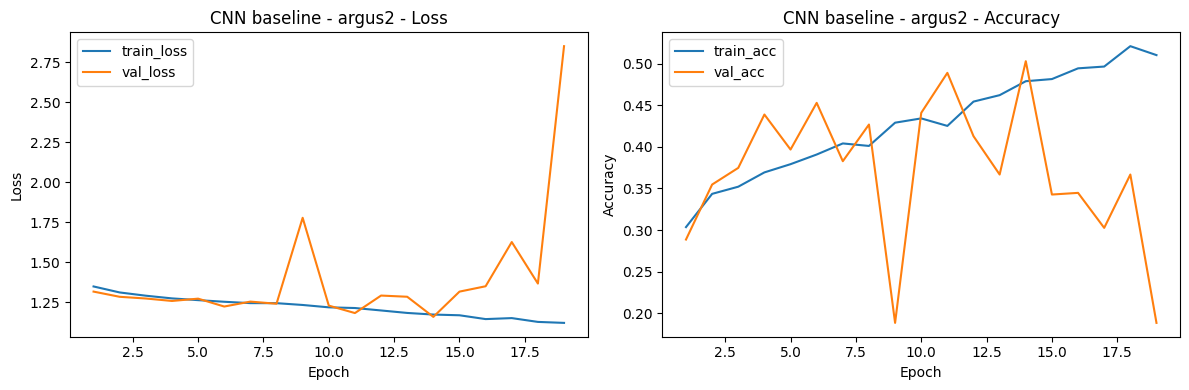

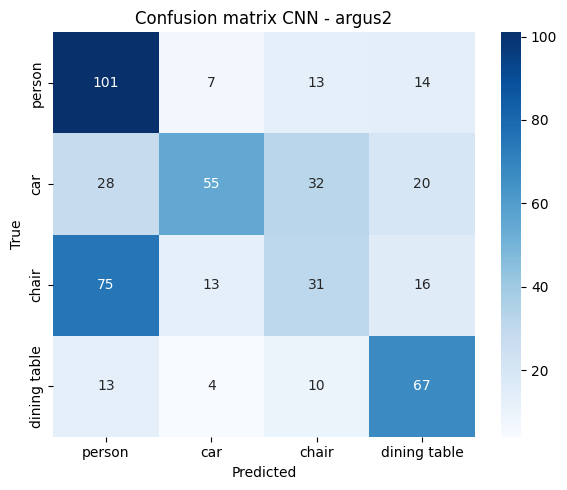

,precision,recall,f1-score,support
person,0.465438,0.748148,0.573864,135.000000
car,0.696203,0.407407,0.514019,135.000000
chair,0.360465,0.229630,0.280543,135.000000
dining table,0.572650,0.712766,0.635071,94.000000
accuracy,0.509018,0.509018,0.509018,0.509018
macro avg,0.523689,0.524488,0.500874,499.000000
weighted avg,0.519666,0.509018,0.489848,499.000000



Evaluación test CNN - prima


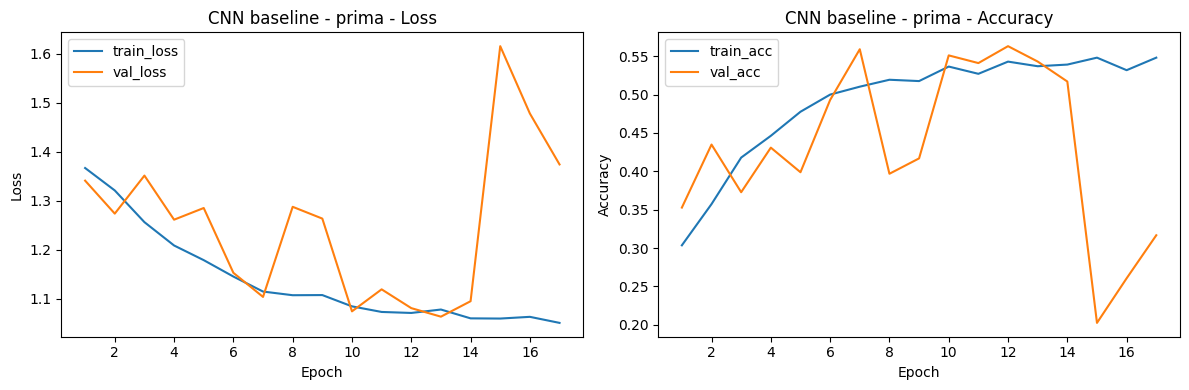

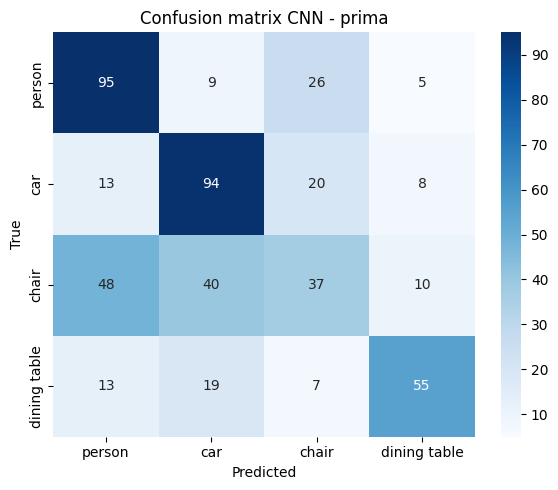

,precision,recall,f1-score,support
person,0.562130,0.703704,0.625000,135.000000
car,0.580247,0.696296,0.632997,135.000000
chair,0.411111,0.274074,0.328889,135.000000
dining table,0.705128,0.585106,0.639535,94.000000
accuracy,0.563126,0.563126,0.563126,0.563126
macro avg,0.564654,0.564795,0.556605,499.000000
weighted avg,0.553112,0.563126,0.549791,499.000000



Evaluación test CNN - alphams


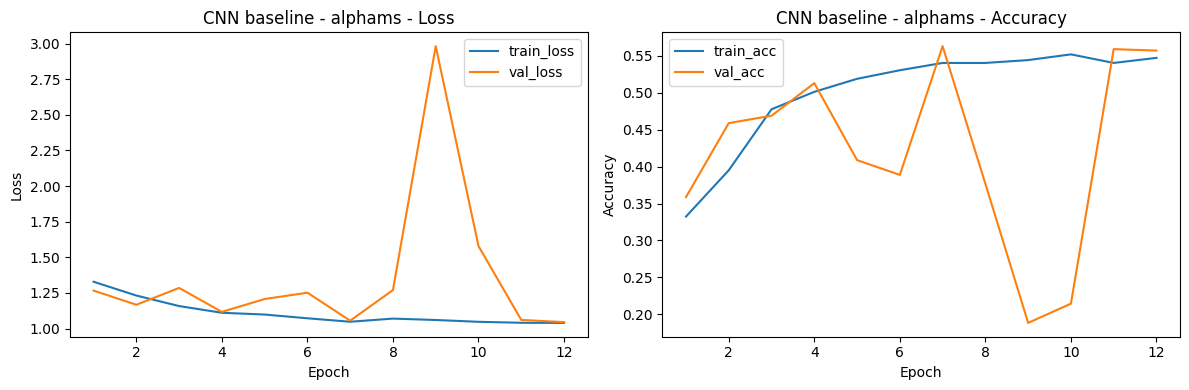

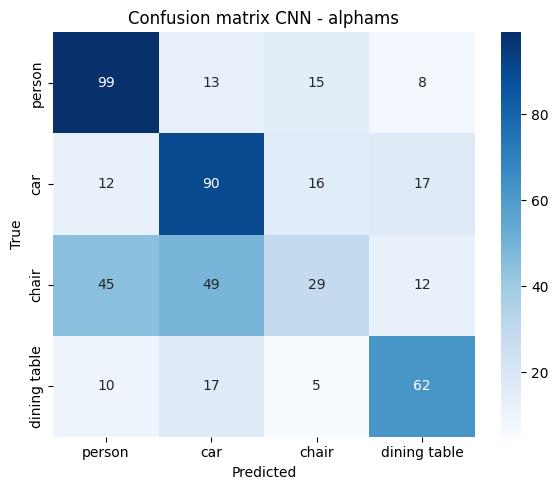

,precision,recall,f1-score,support
person,0.596386,0.733333,0.657807,135.000000
car,0.532544,0.666667,0.592105,135.000000
chair,0.446154,0.214815,0.290000,135.000000
dining table,0.626263,0.659574,0.642487,94.000000
accuracy,0.561122,0.561122,0.561122,0.561122
macro avg,0.550337,0.568597,0.545600,499.000000
weighted avg,0.544098,0.561122,0.537639,499.000000


Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/confusion_matrix_cnn_alphams.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/confusion_matrix_cnn_argus2.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/confusion_matrix_cnn_gru.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/confusion_matrix_cnn_prima.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/training_curves_cnn_alphams.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/training_curves_cnn_argus2.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/training_curves_cnn_gru.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/training_curves_cnn_prima.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/metrics/classification_report_cnn_alphams.

In [14]:
# eval CNN

from torch.utils.data import DataLoader

cnn_test_summary_rows = []

for implant in IMPLANTS:
    print("\n" + "=" * 70)
    print(f"Evaluación test CNN - {implant}")
    print("=" * 70)

    hist = histories_a.get(implant)

    if hist is not None:
        plot_training_curves(
            hist,
            title=f"CNN baseline - {implant}",
            save_path=FIGURES_DIR / f"training_curves_cnn_{implant}.png",
        )
    else:
        print(f"No hay historial para {implant}. Salteo curvas de entrenamiento.")

    df_test_imp = df_test[df_test["implant"] == implant].copy()

    ds_test = PerceptDataset(
        df_test_imp,
        classes=CLASSES,
        transform=val_tf,
    )

    ld_test = DataLoader(
        ds_test,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True,
    )

    y_true, y_pred = predict_all(
        model=models_a[implant],
        loader=ld_test,
        device=DEVICE,
    )

    report_df = save_classification_report(
        y_true=y_true,
        y_pred=y_pred,
        classes=CLASSES,
        save_path=METRICS_DIR / f"classification_report_cnn_{implant}.csv",
    )

    plot_confusion_matrix(
        y_true=y_true,
        y_pred=y_pred,
        classes=CLASSES,
        title=f"Confusion matrix CNN - {implant}",
        save_path=FIGURES_DIR / f"confusion_matrix_cnn_{implant}.png",
    )

    test_acc = (np.array(y_true) == np.array(y_pred)).mean()

    cnn_test_summary_rows.append({
        "model": f"cnn_{implant}",
        "test_accuracy": test_acc,
        "best_lr": cnn_summary_rows[implant]["best_lr"],
        "best_val_acc": cnn_summary_rows[implant]["best_val_acc"],
    })

    display(report_df)

# Sube/actualiza los archivos generados en el Drive compartido
sync_outputs_to_drive()

## Evaluación de Modelos

### Evaluación CNN en conjunto de test
Evalúa cada CNN independiente en el conjunto de test:
1. Carga el modelo entrenado
2. Genera predicciones para todas las muestras de test
3. Calcula métricas (accuracy, precision, recall, F1)
4. Genera matriz de confusión
5. Visualiza ejemplos de predicciones correctas e incorrectas


Evaluación test CNN+GRU


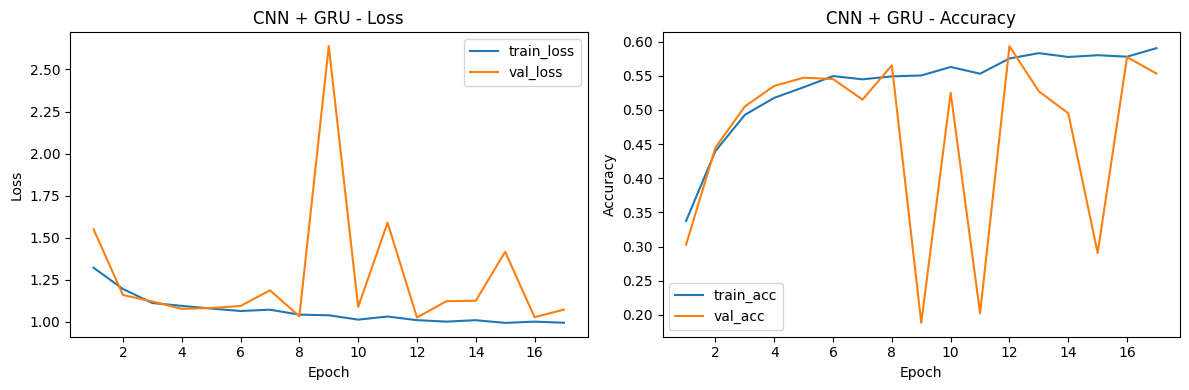

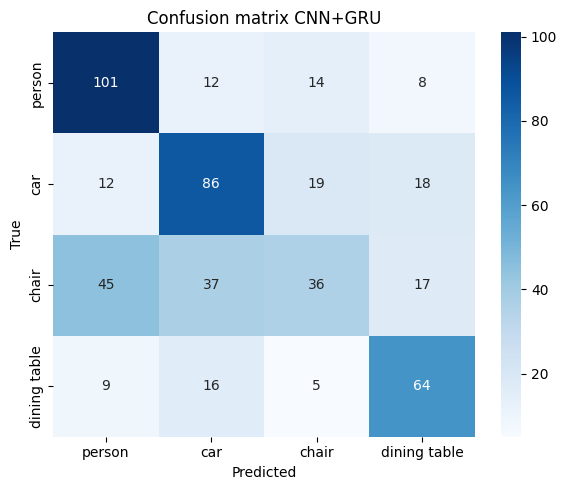

,precision,recall,f1-score,support
person,0.604790,0.748148,0.668874,135.00000
car,0.569536,0.637037,0.601399,135.00000
chair,0.486486,0.266667,0.344498,135.00000
dining table,0.598131,0.680851,0.636816,94.00000
accuracy,0.575150,0.575150,0.575150,0.57515
macro avg,0.564736,0.583176,0.562897,499.00000
weighted avg,0.561992,0.575150,0.556823,499.00000


Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/confusion_matrix_cnn_alphams.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/confusion_matrix_cnn_argus2.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/confusion_matrix_cnn_gru.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/confusion_matrix_cnn_prima.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/training_curves_cnn_alphams.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/training_curves_cnn_argus2.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/training_curves_cnn_gru.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/training_curves_cnn_prima.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/metrics/classification_report_cnn_alphams.

In [15]:
# eval CNN + GRU

print("\n" + "=" * 70)
print("Evaluación test CNN+GRU")
print("=" * 70)

if history_b is not None:
    plot_training_curves(
        history_b,
        title="CNN + GRU",
        save_path=FIGURES_DIR / "training_curves_cnn_gru.png",
    )
else:
    print("No hay historial CNN+GRU. Salteo curvas de entrenamiento.")

ds_seq_test = PerceptSeqDataset(
    df_test,
    implants=IMPLANTS,
    classes=CLASSES,
    transform=val_tf,
)

ld_seq_test = DataLoader(
    ds_seq_test,
    batch_size=SEQ_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

y_true_b, y_pred_b = predict_all(
    model=model_b,
    loader=ld_seq_test,
    device=DEVICE,
)

report_b = save_classification_report(
    y_true=y_true_b,
    y_pred=y_pred_b,
    classes=CLASSES,
    save_path=METRICS_DIR / "classification_report_cnn_gru.csv",
)

plot_confusion_matrix(
    y_true=y_true_b,
    y_pred=y_pred_b,
    classes=CLASSES,
    title="Confusion matrix CNN+GRU",
    save_path=FIGURES_DIR / "confusion_matrix_cnn_gru.png",
)

test_acc_b = (np.array(y_true_b) == np.array(y_pred_b)).mean()

cnn_test_summary_rows.append({
    "model": "cnn_gru",
    "test_accuracy": test_acc_b,
    "best_lr": best_lr_b,
    "best_val_acc": best_acc_b,
})

display(report_b)

# Sube/actualiza los archivos generados en el Drive compartido
sync_outputs_to_drive()

In [16]:
# guardamos modelos

for implant, model in models_a.items():
    model_path = MODELS_DIR / f"cnn_baseline_{implant}.pt"
    torch.save(model.state_dict(), model_path)
    print("Guardado/actualizado:", model_path)

gru_path = MODELS_DIR / "cnn_gru.pt"
torch.save(model_b.state_dict(), gru_path)
print("Guardado/actualizado:", gru_path)

# Sube/actualiza los archivos generados en el Drive compartido
sync_outputs_to_drive()

Guardado/actualizado: /home/jupyter/tp_final_vision_artificial/outputs/models/cnn_baseline_argus2.pt
Guardado/actualizado: /home/jupyter/tp_final_vision_artificial/outputs/models/cnn_baseline_prima.pt
Guardado/actualizado: /home/jupyter/tp_final_vision_artificial/outputs/models/cnn_baseline_alphams.pt
Guardado/actualizado: /home/jupyter/tp_final_vision_artificial/outputs/models/cnn_gru.pt
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/confusion_matrix_cnn_alphams.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/confusion_matrix_cnn_argus2.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/confusion_matrix_cnn_gru.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/confusion_matrix_cnn_prima.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/training_curves_cnn_alphams.png
Subiendo/actualizando: /home/jupyter/tp_final_visio

In [17]:
# KNN vs CNN
df_cnn_summary = pd.DataFrame(cnn_test_summary_rows)
df_cnn_summary.to_csv(METRICS_DIR / "summary_cnn_results.csv", index=False)

df_knn_summary = pd.read_csv(METRICS_DIR / "summary_knn_results.csv")

df_all_results = pd.concat(
    [
        df_knn_summary[["model", "test_accuracy"]],
        df_cnn_summary[["model", "test_accuracy"]],
    ],
    axis=0,
    ignore_index=True,
)

df_all_results = df_all_results.sort_values(
    "test_accuracy",
    ascending=False,
).reset_index(drop=True)

display(df_all_results)

df_all_results.to_csv(METRICS_DIR / "summary_all_results.csv", index=False)

# Sube/actualiza los archivos generados en el Drive compartido
sync_outputs_to_drive()


,model,test_accuracy
0,knn_multi_implant,0.611222
1,cnn_gru,0.575150
2,knn_prima,0.571142
3,knn_alphams,0.567134
4,cnn_prima,0.563126
5,knn_argus2,0.561122
6,cnn_alphams,0.561122
7,cnn_argus2,0.509018


Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/confusion_matrix_cnn_alphams.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/confusion_matrix_cnn_argus2.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/confusion_matrix_cnn_gru.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/confusion_matrix_cnn_prima.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/training_curves_cnn_alphams.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/training_curves_cnn_argus2.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/training_curves_cnn_gru.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/training_curves_cnn_prima.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/metrics/classification_report_cnn_alphams.

In [18]:
print("Modelos:")
!find /home/jupyter/tp_final_vision_artificial/outputs/models -maxdepth 2 -type f

print("Métricas:")
!find /home/jupyter/tp_final_vision_artificial/outputs/metrics -maxdepth 2 -type f

print("Figuras:")
!find /home/jupyter/tp_final_vision_artificial/outputs/figures -maxdepth 2 -type f

sync_outputs_to_drive()

Modelos:
/home/jupyter/tp_final_vision_artificial/outputs/models/cnn_gru.pt
/home/jupyter/tp_final_vision_artificial/outputs/models/cnn_baseline_argus2.pt
/home/jupyter/tp_final_vision_artificial/outputs/models/knn_argus2.joblib
/home/jupyter/tp_final_vision_artificial/outputs/models/cnn_baseline_alphams.pt
/home/jupyter/tp_final_vision_artificial/outputs/models/knn_alphams.joblib
/home/jupyter/tp_final_vision_artificial/outputs/models/knn_multi_implant.joblib
/home/jupyter/tp_final_vision_artificial/outputs/models/cnn_baseline_prima.pt
/home/jupyter/tp_final_vision_artificial/outputs/models/knn_prima.joblib
Métricas:
/home/jupyter/tp_final_vision_artificial/outputs/metrics/knn_argus2_best_params.csv
/home/jupyter/tp_final_vision_artificial/outputs/metrics/knn_alphams_best_params.csv
/home/jupyter/tp_final_vision_artificial/outputs/metrics/lr_search_cnn_alphams.csv
/home/jupyter/tp_final_vision_artificial/outputs/metrics/classification_report_cnn_argus2.csv
/home/jupyter/tp_final_visio

COCO_IMAGES_DIR: /home/jupyter/tp_final_vision_artificial/data/raw/coco/val2017
Existe: True
N imágenes: 5000
Carpeta de salida: /home/jupyter/tp_final_vision_artificial/outputs/figures/test_examples

Visualizando sample_id: 67616_1773132


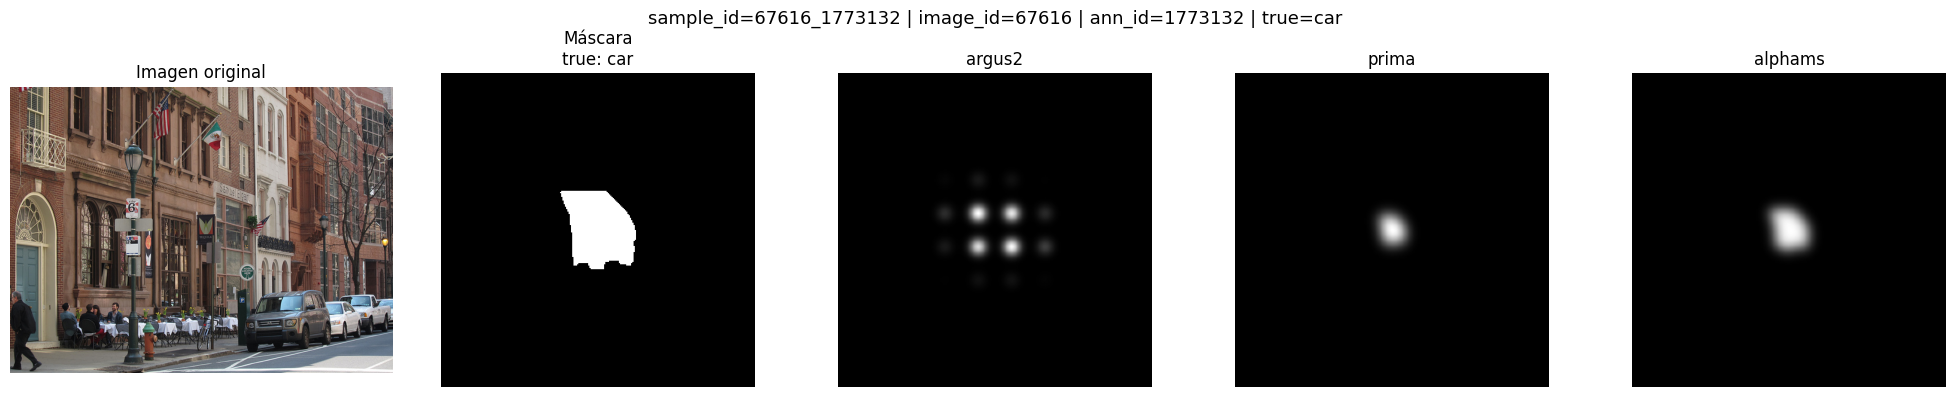

,model,family,implant,true_label,prediction,correct,confidence,prob_person,prob_car,prob_chair,prob_dining table
0,KNN argus2,KNN single,argus2,car,car,True,0.442490,0.149729,0.442490,0.407781,0.000000
1,KNN prima,KNN single,prima,car,car,True,0.467491,0.177743,0.467491,0.354766,0.000000
2,KNN alphams,KNN single,alphams,car,chair,False,0.546475,0.132829,0.320696,0.546475,0.000000
3,KNN multi-implant,KNN multi,all,car,car,True,0.549794,0.175006,0.549794,0.275201,0.000000
4,CNN argus2,CNN single,argus2,car,chair,False,0.316552,0.309655,0.282786,0.316552,0.091007
5,CNN prima,CNN single,prima,car,chair,False,0.388034,0.197918,0.342713,0.388034,0.071334
6,CNN alphams,CNN single,alphams,car,chair,False,0.380916,0.183676,0.369772,0.380916,0.065636
7,CNN + GRU,CNN multi,all,car,car,True,0.458335,0.068512,0.458335,0.364916,0.108238



Visualizando sample_id: 180101_390041


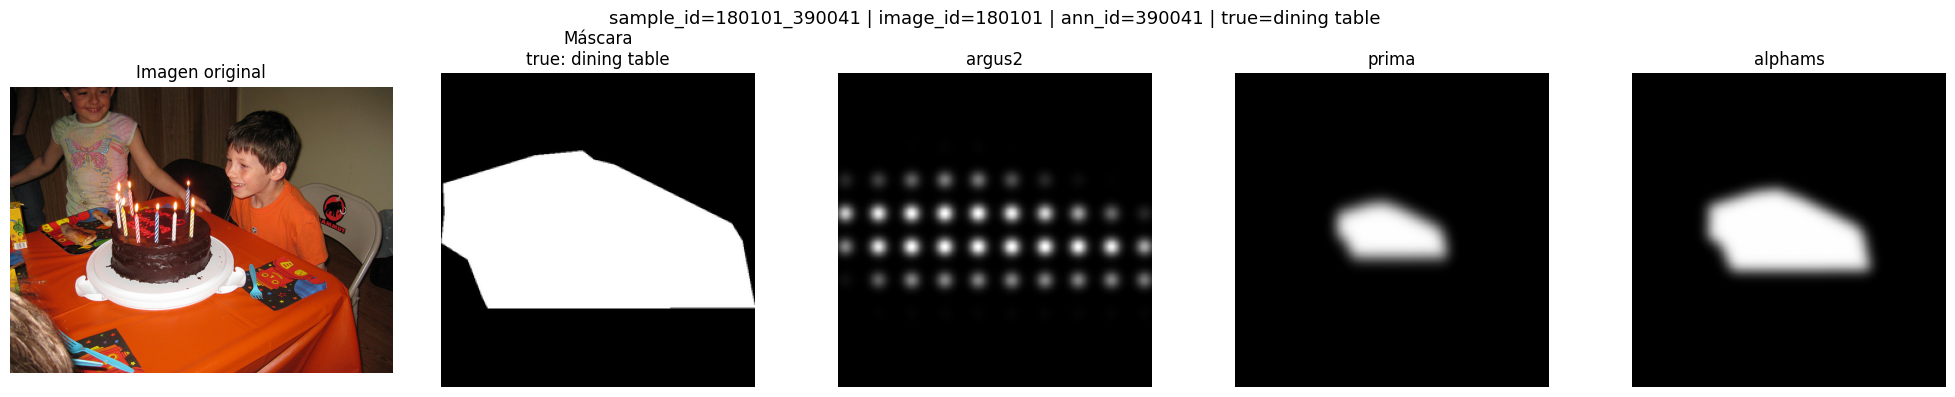

,model,family,implant,true_label,prediction,correct,confidence,prob_person,prob_car,prob_chair,prob_dining table
0,KNN argus2,KNN single,argus2,dining table,car,False,0.428370,0.000000,0.428370,0.178564,0.393066
1,KNN prima,KNN single,prima,dining table,car,False,0.543989,0.000000,0.543989,0.099188,0.356823
2,KNN alphams,KNN single,alphams,dining table,car,False,0.458397,0.000000,0.458397,0.260663,0.280940
3,KNN multi-implant,KNN multi,all,dining table,dining table,True,0.434909,0.000000,0.381722,0.183369,0.434909
4,CNN argus2,CNN single,argus2,dining table,dining table,True,0.757811,0.055663,0.134301,0.052225,0.757811
5,CNN prima,CNN single,prima,dining table,dining table,True,0.497332,0.033261,0.331606,0.137801,0.497332
6,CNN alphams,CNN single,alphams,dining table,dining table,True,0.569599,0.039273,0.249560,0.141568,0.569599
7,CNN + GRU,CNN multi,all,dining table,dining table,True,0.673096,0.050994,0.162143,0.113766,0.673096



Visualizando sample_id: 346232_359552


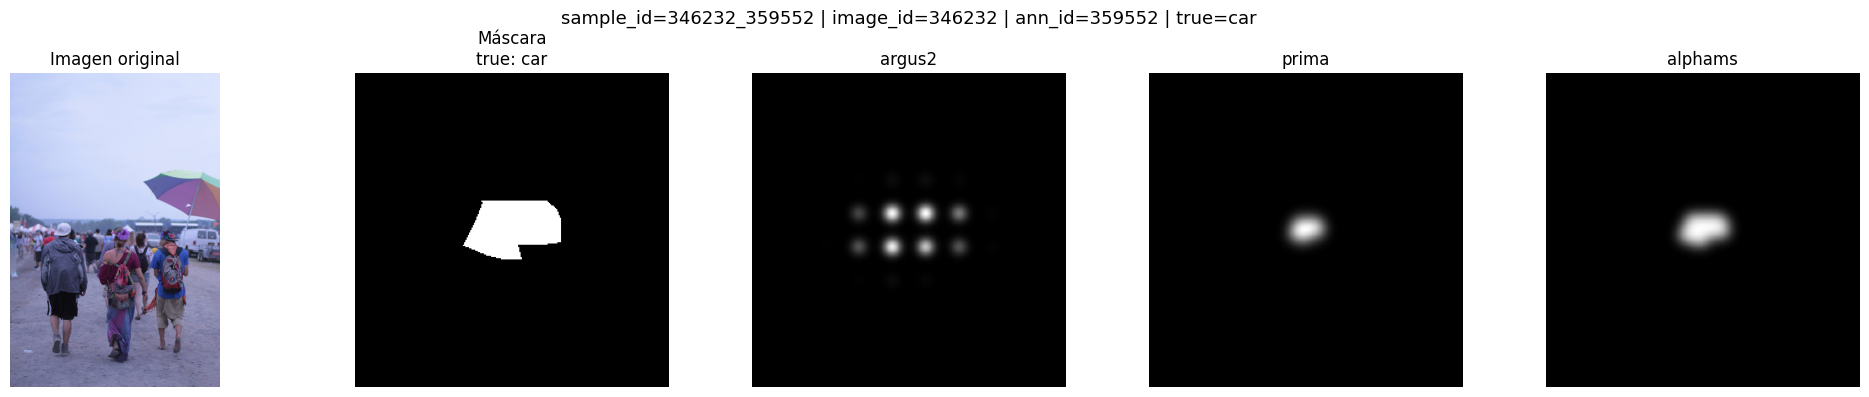

,model,family,implant,true_label,prediction,correct,confidence,prob_person,prob_car,prob_chair,prob_dining table
0,KNN argus2,KNN single,argus2,car,car,True,0.688755,0.000000,0.688755,0.000000,0.311245
1,KNN prima,KNN single,prima,car,car,True,0.791174,0.000000,0.791174,0.000000,0.208826
2,KNN alphams,KNN single,alphams,car,car,True,0.855471,0.000000,0.855471,0.000000,0.144529
3,KNN multi-implant,KNN multi,all,car,car,True,0.804374,0.000000,0.804374,0.000000,0.195626
4,CNN argus2,CNN single,argus2,car,car,True,0.327104,0.256879,0.327104,0.302873,0.113144
5,CNN prima,CNN single,prima,car,car,True,0.504823,0.075333,0.504823,0.299842,0.120002
6,CNN alphams,CNN single,alphams,car,car,True,0.533886,0.063899,0.533886,0.284745,0.117470
7,CNN + GRU,CNN multi,all,car,car,True,0.564815,0.030761,0.564815,0.264535,0.139889



Visualizando sample_id: 295809_346739


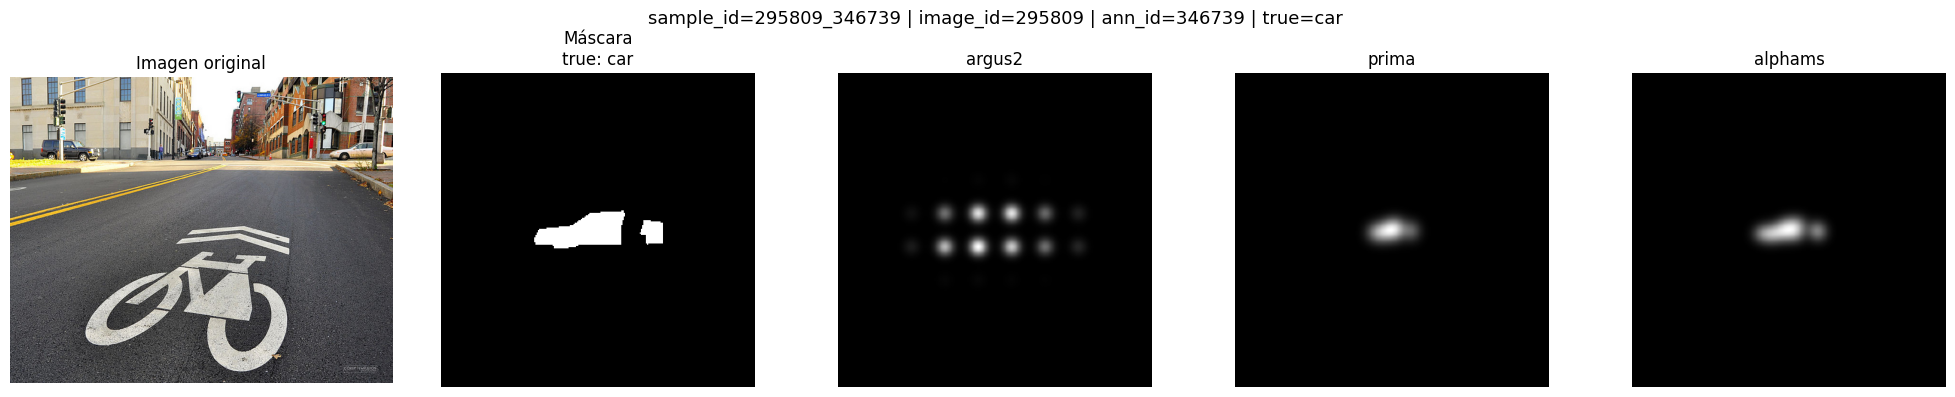

,model,family,implant,true_label,prediction,correct,confidence,prob_person,prob_car,prob_chair,prob_dining table
0,KNN argus2,KNN single,argus2,car,car,True,0.501520,0.000000,0.501520,0.000000,0.498480
1,KNN prima,KNN single,prima,car,car,True,0.441272,0.000000,0.441272,0.172470,0.386258
2,KNN alphams,KNN single,alphams,car,car,True,0.570794,0.000000,0.570794,0.152852,0.276354
3,KNN multi-implant,KNN multi,all,car,car,True,0.610759,0.000000,0.610759,0.000000,0.389241
4,CNN argus2,CNN single,argus2,car,car,True,0.342555,0.216520,0.342555,0.285480,0.155444
5,CNN prima,CNN single,prima,car,car,True,0.524296,0.042054,0.524296,0.224995,0.208655
6,CNN alphams,CNN single,alphams,car,car,True,0.500749,0.033642,0.500749,0.215942,0.249668
7,CNN + GRU,CNN multi,all,car,car,True,0.522716,0.025377,0.522716,0.227156,0.224752



Visualizando sample_id: 351810_1965598


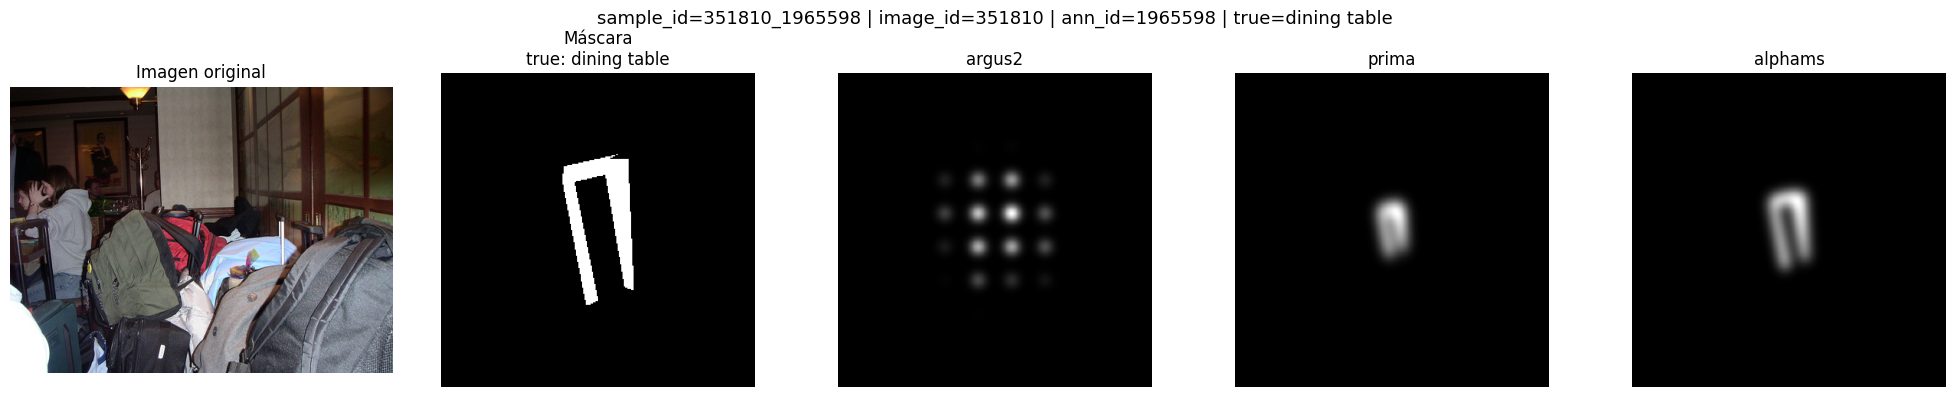

,model,family,implant,true_label,prediction,correct,confidence,prob_person,prob_car,prob_chair,prob_dining table
0,KNN argus2,KNN single,argus2,dining table,chair,False,0.718665,0.137913,0.000000,0.718665,0.143422
1,KNN prima,KNN single,prima,dining table,chair,False,0.556787,0.261565,0.083403,0.556787,0.098245
2,KNN alphams,KNN single,alphams,dining table,chair,False,0.738999,0.261001,0.000000,0.738999,0.000000
3,KNN multi-implant,KNN multi,all,dining table,chair,False,0.556649,0.343879,0.000000,0.556649,0.099472
4,CNN argus2,CNN single,argus2,dining table,person,False,0.402796,0.402796,0.194160,0.312684,0.090360
5,CNN prima,CNN single,prima,dining table,chair,False,0.383410,0.304595,0.245920,0.383410,0.066075
6,CNN alphams,CNN single,alphams,dining table,chair,False,0.375888,0.311734,0.242145,0.375888,0.070234
7,CNN + GRU,CNN multi,all,dining table,chair,False,0.449696,0.218444,0.244104,0.449696,0.087756


Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/confusion_matrix_cnn_alphams.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/confusion_matrix_cnn_argus2.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/confusion_matrix_cnn_gru.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/confusion_matrix_cnn_prima.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/test_examples/test_example_180101_390041.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/test_examples/test_example_295809_346739.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/test_examples/test_example_346232_359552.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_artificial/outputs/figures/test_examples/test_example_351810_1965598.png
Subiendo/actualizando: /home/jupyter/tp_final_vision_a

In [19]:
# visualizacion de varios ejemplos de test

COCO_IMAGES_DIR = DATA_DIR / "raw" / "coco" / "val2017"

TEST_EXAMPLES_DIR = FIGURES_DIR / "test_examples"
TEST_EXAMPLES_DIR.mkdir(parents=True, exist_ok=True)

print("COCO_IMAGES_DIR:", COCO_IMAGES_DIR)
print("Existe:", COCO_IMAGES_DIR.exists())
print("N imágenes:", len(list(COCO_IMAGES_DIR.glob("*.jpg"))))
print("Carpeta de salida:", TEST_EXAMPLES_DIR)

sample_ids = (
    df_test["sample_id"]
    .drop_duplicates()
    .sample(5, random_state=42)
    .tolist()
)

for sample_id in sample_ids:
    print("\nVisualizando sample_id:", sample_id)

    pred_df = visualize_sample_predictions(
        df=df_test,
        sample_id=sample_id,
        classes=CLASSES,
        implants=IMPLANTS,
        coco_images_dir=COCO_IMAGES_DIR,
        knn_results=knn_results,
        cnn_models=models_a,
        cnn_gru_model=model_b,
        transform=val_tf,
        device=DEVICE,
        knn_img_size=KNN_IMG_SIZE,
        save_figure_path=TEST_EXAMPLES_DIR / f"test_example_{sample_id}.png",
        sort_by_confidence=False,
    )

    pred_df.to_csv(
        TEST_EXAMPLES_DIR / f"test_example_predictions_{sample_id}.csv",
        index=False,
    )

sync_outputs_to_drive()